TASK 4:-
Plot a time series line chart to show the trend of total installs over time, segmented by app category.
Your condition requirement:-
- Time series line chart
- Trend of total installs over time
- Segmented by app category
- Highlight regions where month-over-month growth > 20%
- App name does not start with X, Y, or Z
- App name does not contain the letter S (case-insensitive)
- Reviews > 500
- Categories start with B, C, or E
- Beauty translated to सौंदर्य (Hindi)
- Business translated to வணிகம் (Tamil)
- Dating translated to Partnersuche (German)
- Graph visible only between 6 PM and 9 PM IST
- No graph shown outside the allowed time

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import pytz

In [38]:
apps_df = pd.read_csv(r"C:\Users\gk442\Downloads\Play Store Data.csv")
reviews_df = pd.read_csv(r"C:\Users\gk442\Downloads\User Reviews.csv")

In [39]:
task4_df = apps_df.copy()

In [40]:
task4_df["Reviews"] = pd.to_numeric(task4_df["Reviews"], errors="coerce")

In [41]:
task4_df["Installs"] = (
    task4_df["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

task4_df["Installs"] = pd.to_numeric(task4_df["Installs"], errors="coerce")

In [42]:
task4_df["Last Updated"] = pd.to_datetime(
    task4_df["Last Updated"],
    errors="coerce"
)

In [43]:
task4_df = task4_df[
    task4_df["Category"].str.startswith(("B","C","E"), na=False)
]

In [44]:
task4_df = task4_df[
    task4_df["Reviews"] > 500
]

In [45]:
task4_df = task4_df[
    ~task4_df["App"].str.startswith(("X","Y","Z"), na=False)
]

In [46]:
task4_df = task4_df[
    ~task4_df["App"].str.contains("s", case=False, na=False)
]

In [47]:
task4_df["Category"] = task4_df["Category"].replace({

    "BEAUTY":"सौंदर्य",      # Hindi

    "BUSINESS":"வணிகம்",   # Tamil

    "DATING":"Dating"       # temporary
})

In [48]:
task4_df["Category"] = task4_df["Category"].replace({

    "Dating":"Partnersuche"

})

In [49]:
task4_df["Category"] = task4_df["Category"].replace({
    "BEAUTY":"सौंदर्य",
    "BUSINESS":"வணிகம்",
    "DATING":"Partnersuche"
})

In [50]:
task4_df["Month"] = task4_df["Last Updated"].dt.to_period("M").dt.to_timestamp()

In [51]:
monthly_installs = (
    task4_df
    .groupby(["Month", "Category"], as_index=False)["Installs"]
    .sum()
)

monthly_installs = monthly_installs.sort_values(
    ["Category", "Month"]
)

In [52]:
monthly_installs["Month"] = pd.to_datetime(monthly_installs["Month"])

In [53]:
monthly_installs.head()

,Month,Category,Installs
5,2014-10-01,BOOKS_AND_REFERENCE,500000.0
6,2014-11-01,BOOKS_AND_REFERENCE,5000000.0
10,2015-07-01,BOOKS_AND_REFERENCE,10000000.0
18,2016-06-01,BOOKS_AND_REFERENCE,60000.0
21,2016-08-01,BOOKS_AND_REFERENCE,100000.0


In [54]:
monthly_installs["Growth %"] = (
    monthly_installs.groupby("Category")["Installs"]
    .pct_change()
)   

In [55]:
monthly_installs.head(10)

,Month,Category,Installs,Growth %
5,2014-10-01,BOOKS_AND_REFERENCE,500000.0,NaN
6,2014-11-01,BOOKS_AND_REFERENCE,5000000.0,9.000000
10,2015-07-01,BOOKS_AND_REFERENCE,10000000.0,1.000000
18,2016-06-01,BOOKS_AND_REFERENCE,60000.0,-0.994000
21,2016-08-01,BOOKS_AND_REFERENCE,100000.0,0.666667
27,2017-02-01,BOOKS_AND_REFERENCE,100000.0,0.000000
29,2017-04-01,BOOKS_AND_REFERENCE,1000000.0,9.000000
31,2017-05-01,BOOKS_AND_REFERENCE,100000.0,-0.900000
32,2017-07-01,BOOKS_AND_REFERENCE,100000.0,0.000000
33,2017-08-01,BOOKS_AND_REFERENCE,10010000.0,99.100000


In [56]:
monthly_installs["Highlight"] = (
    monthly_installs["Growth %"] > 0.20
)

In [57]:
monthly_installs.head(10)

,Month,Category,Installs,Growth %,Highlight
5,2014-10-01,BOOKS_AND_REFERENCE,500000.0,NaN,False
6,2014-11-01,BOOKS_AND_REFERENCE,5000000.0,9.000000,True
10,2015-07-01,BOOKS_AND_REFERENCE,10000000.0,1.000000,True
18,2016-06-01,BOOKS_AND_REFERENCE,60000.0,-0.994000,False
21,2016-08-01,BOOKS_AND_REFERENCE,100000.0,0.666667,True
27,2017-02-01,BOOKS_AND_REFERENCE,100000.0,0.000000,False
29,2017-04-01,BOOKS_AND_REFERENCE,1000000.0,9.000000,True
31,2017-05-01,BOOKS_AND_REFERENCE,100000.0,-0.900000,False
32,2017-07-01,BOOKS_AND_REFERENCE,100000.0,0.000000,False
33,2017-08-01,BOOKS_AND_REFERENCE,10010000.0,99.100000,True


In [58]:
ist = pytz.timezone("Asia/Kolkata")

hour = datetime.now(ist).hour

In [59]:
monthly_installs.columns

Index(['Month', 'Category', 'Installs', 'Growth %', 'Highlight'], dtype='str')

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, 'Jan-1970'),
  Text(0.2, 0, 'Jan-1970'),
  Text(0.4, 0, 'Jan-1970'),
  Text(0.6000000000000001, 0, 'Jan-1970'),
  Text(0.8, 0, 'Jan-1970'),
  Text(1.0, 0, 'Jan-1970')])

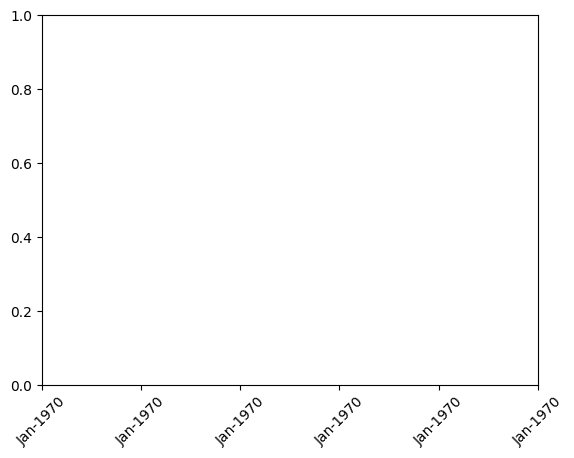

In [60]:
import matplotlib.dates as mdates

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%b-%Y")
)

plt.xticks(rotation=45)

In [61]:
if 18 <= hour < 21:

    plt.figure(figsize=(14,7))

    categories = monthly_installs["Category"].unique()

    for category in categories:

        temp = monthly_installs[
            monthly_installs["Category"] == category
        ]

        plt.plot(
            temp["Month"],
            temp["Installs"],
            marker="o",
            linewidth=2,
            label=category
        )

        # Highlight Growth >20%

        plt.fill_between(
            temp["Month"],
            0,
            temp["Installs"],
            where=temp["Highlight"],
            alpha=0.25
        )

    plt.title("Total Installs Over Time by Category")
    plt.xlabel("Month")
    plt.ylabel("Total Installs")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)

    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

TASK 5:-
Plot a bubble chart to analyze the relationship between app size (in MB) and average rating, with the bubble size representing the number of installs.

Requirement:-
- Bubble chart	
- X-axis = Size (MB)	
- Y-axis = Rating	
- Bubble Size = Installs	
- Rating > 3.5	
- Categories filtered	
- Reviews > 500	
- App name should not contain "S"	
- Sentiment Subjectivity > 0.5	
- Installs > 50K	
- GAME bubbles in Pink	
- Beauty translated to Hindi	
- Business translated to Tamil	
- Dating translated to German	
- Visible only between 5 PM and 7 PM IST

In [62]:
task5_df = apps_df.copy()

STEP 1:- Clean App Dataset

In [63]:
## INSTALLS
task5_df["Installs"] = (
    task5_df["Installs"]
    .astype(str)
    .str.replace(",","",regex=False)
    .str.replace("+","",regex=False)
)

task5_df["Installs"] = pd.to_numeric(task5_df["Installs"],errors="coerce")

In [64]:
## REVIEWS
task5_df["Reviews"] = pd.to_numeric(
    task5_df["Reviews"],
    errors="coerce"
)

In [65]:
## RATING
task5_df["Rating"] = pd.to_numeric(
    task5_df["Rating"],
    errors="coerce"
)

In [66]:
## SIZE
task5_df["Size"] = task5_df["Size"].astype(str)

task5_df["Size_MB"] = (
    task5_df["Size"]
    .str.replace("M","",regex=False)
    .str.replace("k","",regex=False)
)

task5_df["Size_MB"] = pd.to_numeric(
    task5_df["Size_MB"],
    errors="coerce"
)

STEP 2:- Clean Reviews Dataset

In [67]:
reviews_df["Sentiment_Subjectivity"] = pd.to_numeric(
    reviews_df["Sentiment_Subjectivity"],
    errors="coerce"
)

STEP 3:- MERGE BOTH DATASET

In [68]:
task5_df = task5_df.merge(
    reviews_df[["App","Sentiment_Subjectivity"]],
    on="App",
    how="left"
)

STEP 4:- Translate Categories

In [69]:
task5_df["Category"] = task5_df["Category"].replace({
    "BEAUTY":"सौंदर्य",
    "BUSINESS":"வணிகம்",
    "DATING":"Dating (Deutsch)"
})

STEP 5:- Select Categories

In [70]:
categories = [
"GAME",
"सौंदर्य",
"வணிகம்",
"COMICS",
"COMMUNICATION",
"Dating (Deutsch)",
"ENTERTAINMENT",
"SOCIAL",
"EVENTS"
]

STEP 6:- Apply Filters

In [71]:
task5_df = task5_df[
(task5_df["Rating"]>3.5)&
(task5_df["Category"].isin(categories))&
(task5_df["Reviews"]>500)&
(~task5_df["App"].str.contains("S",case=False,na=False))&
(task5_df["Sentiment_Subjectivity"]>0.5)&
(task5_df["Installs"]>50000)
]

STEP 7:- Time Condition (5 PM–7 PM IST)

In [72]:
from datetime import datetime
import pytz
india = pytz.timezone("Asia/Kolkata")
hour = datetime.now(india).hour

STEP 10:- Bubble Chart

In [95]:
import matplotlib.pyplot as plt

if 17 <= hour < 19:
    plt.figure(figsize=(14,8))
    colors = []
    for cat in task5_df["Category"]:
        if cat=="GAME":
            colors.append("pink")
        else:
            colors.append("skyblue")
    plt.scatter(
        task5_df["Size_MB"],
        task5_df["Rating"],
        s=task5_df["Installs"]/1000,
        c=colors,
        alpha=0.6,
        edgecolors="black"
    )
    plt.xlabel("App Size (MB)",fontsize=12)
    plt.ylabel("Average Rating",fontsize=12)
    plt.title("Bubble Chart: App Size vs Rating",fontsize=15)
    from matplotlib.lines import Line2D
    legend_elements = [
    Line2D([0], [0],
           marker='o',
           color='w',
           label='GAME',
           markerfacecolor='pink',
           markersize=12),
    Line2D([0], [0],
           marker='o',
           color='w',
           label='Other Categories',
           markerfacecolor='skyblue',
           markersize=12)
    ]
    plt.legend(handles=legend_elements)  

    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("🕔 This chart is available only between 5 PM IST and 7 PM IST.")

🕔 This chart is available only between 5 PM IST and 7 PM IST.


now this without timeline

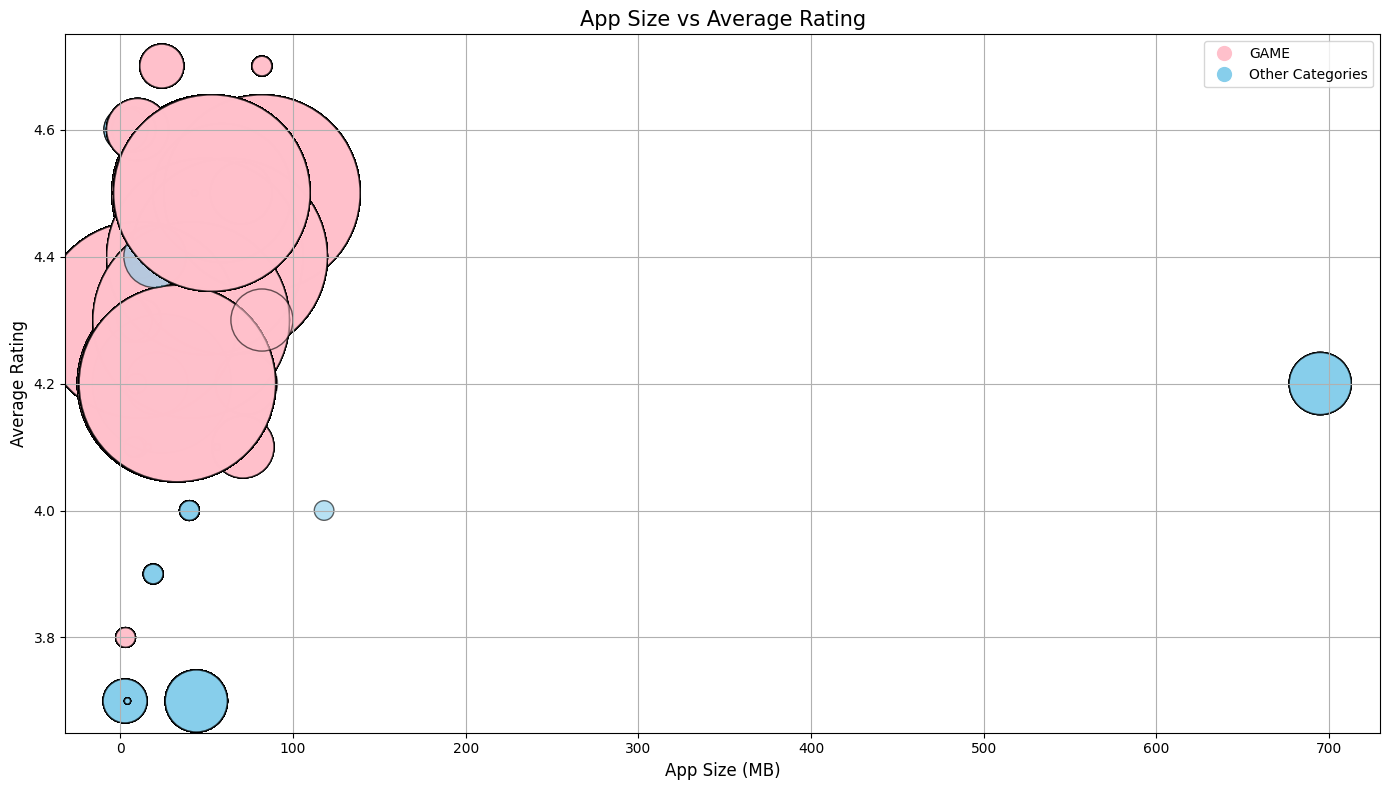

In [74]:
plt.figure(figsize=(14,8))

# Color Game category as Pink
colors = []

for cat in task5_df["Category"]:
    if cat == "GAME":
        colors.append("pink")
    else:
        colors.append("skyblue")

plt.scatter(
    task5_df["Size_MB"],
    task5_df["Rating"],
    s=task5_df["Installs"]/5000,   # Bubble size
    c=colors,
    alpha=0.6,
    edgecolors="black"
)

plt.xlabel("App Size (MB)", fontsize=12)
plt.ylabel("Average Rating", fontsize=12)
plt.title("App Size vs Average Rating", fontsize=15)

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0],
           marker='o',
           color='w',
           label='GAME',
           markerfacecolor='pink',
           markersize=12),

    Line2D([0], [0],
           marker='o',
           color='w',
           label='Other Categories',
           markerfacecolor='skyblue',
           markersize=12)
]

plt.legend(handles=legend_elements)

plt.grid(True)
plt.tight_layout()
plt.show()

TASK 6:-
a stacked area chart to visualize the cumulative number of installs over time for each app category

Requirement:-
- Stacked Area Chart	
- Cumulative installs over time	
- Separate color band for each category	
- Rating ≥ 4.2	
- No numbers in app name	
- Category starts with T or P	
- Reviews >1000	
- Size 20–80 MB	
- Travel & Local translated to French	
- Productivity translated to Spanish	
- Photography translated to Japanese	
- Highlight months with >25% MoM growth	(red shaded band)
- Visible only between 4 PM–6 PM IST	

STEP 1:- Copy the DataFrame

In [75]:
task6_df = apps_df.copy()

STEP 2:- Clean Required Columns

In [ ]:
## RATING
task6_df["Rating"] = pd.to_numeric(task6_df["Rating"], errors="coerce")

In [ ]:
## REVIEWS
task6_df["Reviews"] = pd.to_numeric(task6_df["Reviews"], errors="coerce")

In [ ]:
## INSTALLS
task6_df["Installs"] = (
    task6_df["Installs"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("+", "", regex=False)
)

task6_df["Installs"] = pd.to_numeric(task6_df["Installs"], errors="coerce")

In [ ]:
## SIZE(convert to MB)
task6_df["Size"] = task6_df["Size"].astype(str)

task6_df["Size_MB"] = (
    task6_df["Size"]
    .str.replace("M","",regex=False)
    .str.replace("k","",regex=False)
)

task6_df["Size_MB"] = pd.to_numeric(task6_df["Size_MB"], errors="coerce")

In [ ]:
## CONVERT KB INTO MB
task6_df.loc[
    task6_df["Size"].str.contains("k", case=False, na=False),
    "Size_MB"
] = (
    task6_df.loc[
        task6_df["Size"].str.contains("k", case=False, na=False),
        "Size_MB"
    ] / 1024
)

In [ ]:
## REMOVE "Varies with device"
task6_df = task6_df.dropna(subset=["Size_MB"])

STEP 3:- Apply Filters

In [82]:
task6_df = task6_df[
(task6_df["Rating"] >= 4.2) &
(task6_df["Reviews"] > 1000) &
(task6_df["Size_MB"].between(20,80)) &
(task6_df["Category"].str.startswith(("T","P"))) &
(~task6_df["App"].str.contains(r"\d", regex=True, na=False))
]

STEP 4:- Translate Categories

In [83]:
task6_df["Category"] = task6_df["Category"].replace({
"TRAVEL_AND_LOCAL":"Voyage et Local",
"PRODUCTIVITY":"Productividad",
"PHOTOGRAPHY":"写真"
})

STEP 5:- Create Month Column

In [84]:
task6_df["Last Updated"] = pd.to_datetime(
    task6_df["Last Updated"],
    errors="coerce"
)
task6_df["Month"] = task6_df["Last Updated"].dt.to_period("M").astype(str)

STEP 6:- Monthly Installs

In [85]:
monthly = (
task6_df
.groupby(["Month","Category"],as_index=False)["Installs"]
.sum()
)

STEP 7:- Pivot Table

In [86]:
pivot = monthly.pivot(
index="Month",
columns="Category",
values="Installs"
).fillna(0)

STEP 8:- Calculate Monthly Growth

In [87]:
total_installs = pivot.sum(axis=1)
growth = total_installs.pct_change()

STEP 9:- Time Condition

In [88]:
from datetime import datetime
import pytz
india = pytz.timezone("Asia/Kolkata")
hour = datetime.now(india).hour

STEP 10:- Plot Stacked Area Chart

C:\Users\gk442\AppData\Local\Temp\ipykernel_11044\4281376844.py:25: UserWarning: Glyph 20889 (\N{CJK UNIFIED IDEOGRAPH-5199}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gk442\AppData\Local\Temp\ipykernel_11044\4281376844.py:25: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


<Figure size 1600x800 with 0 Axes>

c:\Users\gk442\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20889 (\N{CJK UNIFIED IDEOGRAPH-5199}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\gk442\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


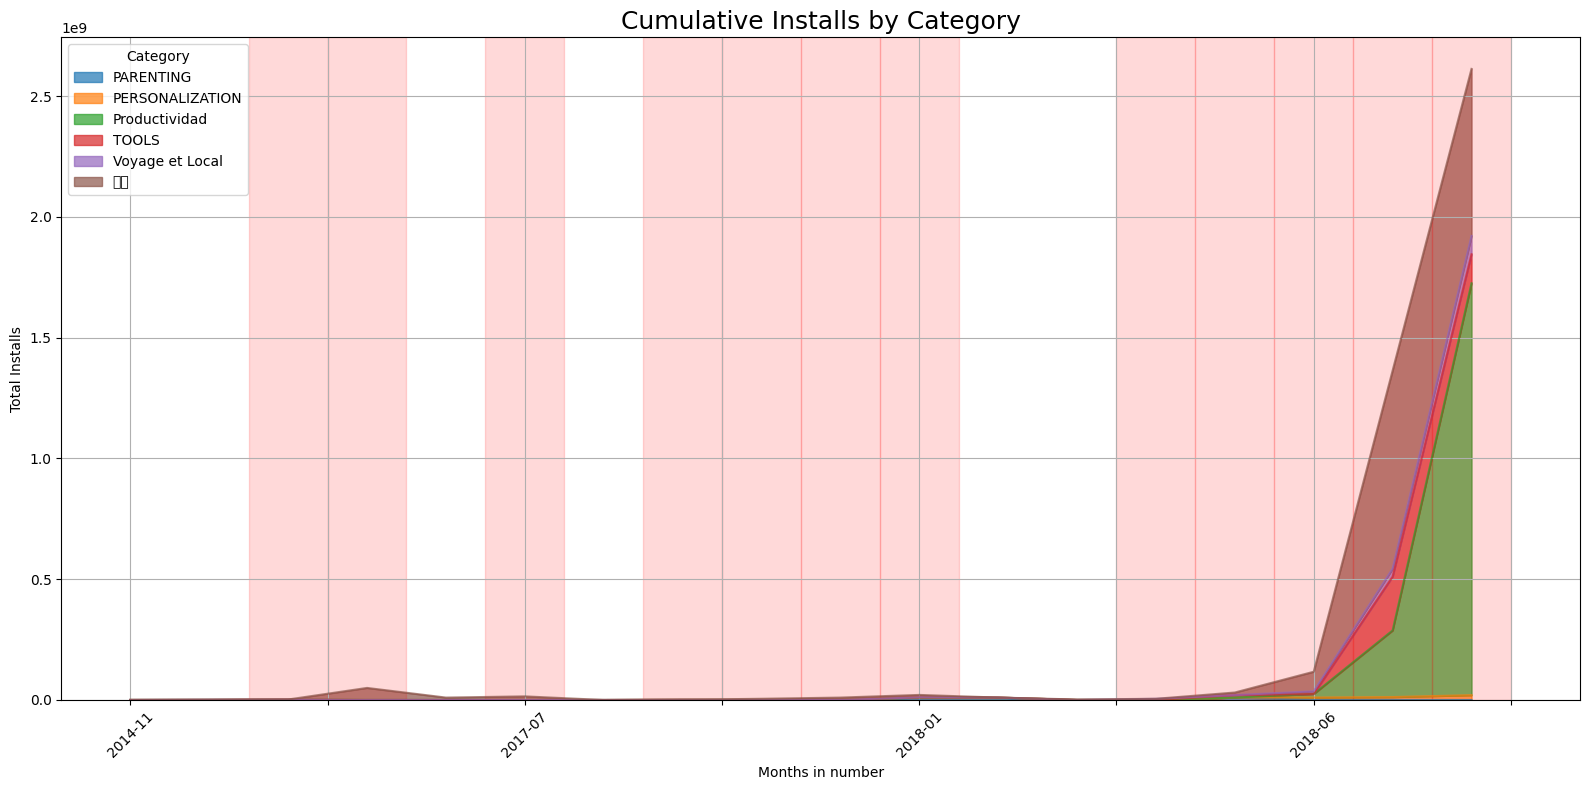

In [99]:
import matplotlib.pyplot as plt

if 16 <= hour < 18:
    plt.figure(figsize=(16,8))
    ax = pivot.plot.area(
        figsize=(16,8),
        alpha=0.7
    )
    for i, g in enumerate(growth):
        if pd.notna(g) and g > 0.25:
            ax.axvspan(
                i-0.5,
                i+0.5,
                color="red",
                alpha=0.15
            )
    plt.title(
        "Cumulative Installs by Category",
        fontsize=18
    )
    plt.xlabel("Months in number")
    plt.ylabel("Total Installs")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("⏰ This chart is available only between 4 PM IST and 6 PM IST.")

now without timeline

In [102]:
task6_df["Rating"] = pd.to_numeric(task6_df["Rating"], errors="coerce")
task6_df["Reviews"] = pd.to_numeric(task6_df["Reviews"], errors="coerce")

task6_df["Installs"] = (
    task6_df["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)
task6_df["Installs"] = pd.to_numeric(task6_df["Installs"], errors="coerce")

task6_df["Size"] = task6_df["Size"].astype(str)

task6_df["Size_MB"] = (
    task6_df["Size"]
    .str.replace("M", "", regex=False)
    .str.replace("k", "", regex=False)
)

task6_df["Size_MB"] = pd.to_numeric(task6_df["Size_MB"], errors="coerce")

task6_df.loc[
    task6_df["Size"].str.contains("k", case=False, na=False),
    "Size_MB"
] /= 1024

task6_df = task6_df.dropna(subset=["Size_MB"])

In [101]:
task6_df = task6_df[
    (task6_df["Rating"] >= 4.2) &
    (task6_df["Reviews"] > 1000) &
    (task6_df["Size_MB"].between(20, 80)) &
    (task6_df["Category"].str.startswith(("T", "P"))) &
    (~task6_df["App"].str.contains(r"\d", regex=True, na=False))
]

In [100]:
task6_df["Category"] = task6_df["Category"].replace({
    "TRAVEL_AND_LOCAL": "Voyage et Local",
    "PRODUCTIVITY": "Productividad",
    "PHOTOGRAPHY": "写真"
})

In [96]:
category_installs = (
    task6_df
    .groupby("Category", as_index=False)["Installs"]
    .sum()
)

In [97]:
category_installs["Cumulative"] = (
    category_installs["Installs"].cumsum()
)

C:\Users\gk442\AppData\Local\Temp\ipykernel_11044\1230369053.py:15: UserWarning: Glyph 20889 (\N{CJK UNIFIED IDEOGRAPH-5199}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gk442\AppData\Local\Temp\ipykernel_11044\1230369053.py:15: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\gk442\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20889 (\N{CJK UNIFIED IDEOGRAPH-5199}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\gk442\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


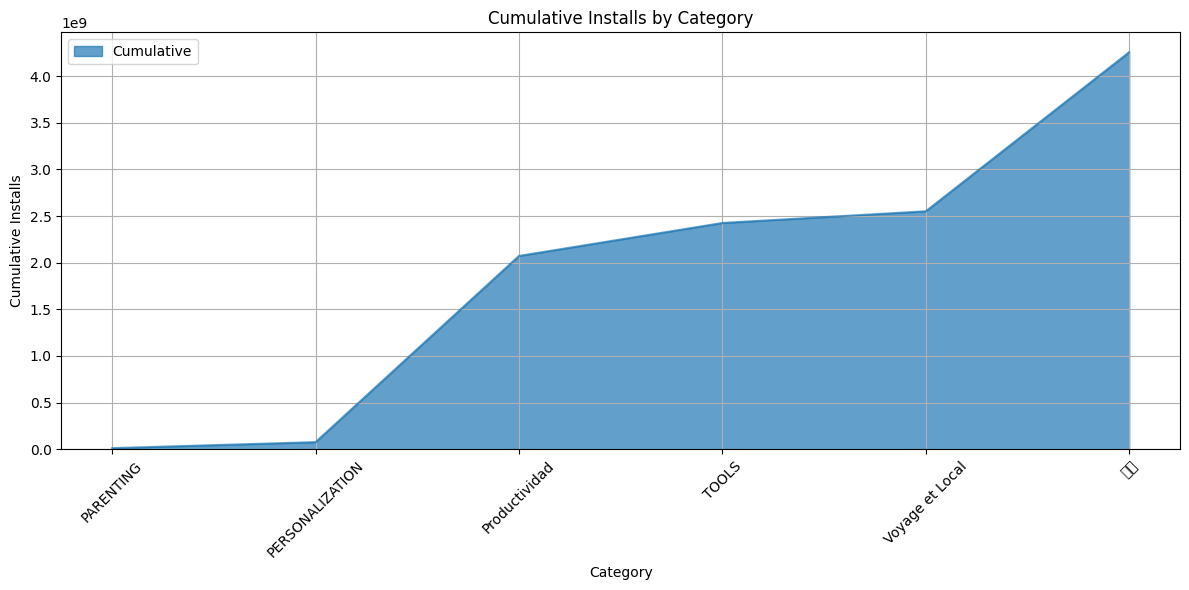

In [103]:
import matplotlib.pyplot as plt

plot_df = category_installs.set_index("Category")[["Cumulative"]]

ax = plot_df.plot.area(
    figsize=(12, 6),
    alpha=0.7
)

plt.title("Cumulative Installs by Category")
plt.xlabel("Category")
plt.ylabel("Cumulative Installs")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()